In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [18]:
network_type = "TwoRR"
N = 10000
z = 6
z_bar = 6
cMin = 0.1
file_type = "final"
ini_type = "nonbfs"
index_cols = [] if file_type == "final" else ["time"]
index_cols.extend(["itr", "lambda", "mu", "rho", "c", "edge_num"])

In [ ]:
c_list = [2.0]
edge_num_list = [8]

In [20]:
sim_results=[[] for _ in range(len(c_list))]
rho0_values = [1.0]

N = 10000

for cidx, c in enumerate(c_list):
    dfs = pd.DataFrame()
    for edge_num in edge_num_list:
        df = pd.DataFrame()
        sim_path = os.path.abspath(os.path.join('..',f'java-project/output/sis/{network_type}/edgeNum={int(edge_num)}/z={z}/N={N}cMin={c:.2f}{file_type}{ini_type}'))
        print(sim_path)
        for path in Path(sim_path).glob('**/results_*.csv'):
            df = pd.concat([df, pd.read_csv(path)])

        df["edge_num"] = edge_num
        dfs = pd.concat([dfs, df], ignore_index=True)
    sim_results[cidx] = dfs

display(sim_results[0])
sim_results = sim_results[cidx].set_index(index_cols).to_xarray()
print(sim_results)

if network_type == "TwoRR":
    N = 2 * N

/Users/black/trend-sar/java-project/output/sis/TwoRR/edgeNum=4/z=6/N=10000cMin=2.00finalnonbfs


,edge_num


KeyError: "None of ['itr', 'lambda', 'mu', 'rho', 'c'] are in the columns"

In [ ]:
ebcm_index_cols = ["lambda", "mu0", "c", "rho", "n_r"]
is_final = "true"
index_cols = [] if is_final == "true" else ["time"]
index_cols.extend(["lambda", "mu0", "c", "rho", "n_r"])

df = pd.DataFrame()
for nidx, n_r in enumerate(edge_num_list):
    ame_path = os.path.abspath(
        os.path.join(
            '..',
            f'ame/sis/c={c:.1f}/z={z}_z_bar={z_bar}n_r={int(n_r/2)}/is_final={is_final}.csv'
            # f'c-lang/ame/sis/z={z}/is_final={is_final}.csv'
        )
    )
    ame=pd.read_csv(ame_path)
    df = pd.concat([df, ame], ignore_index=True)
df["n_r"] = n_r
ame = xr.Dataset.from_dataframe(df.set_index(ebcm_index_cols))
print(ame.dims)
print(ame["I"]["n_r"])

FrozenMappingWarningOnValuesAccess({'lambda': 1001, 'mu0': 1, 'c': 1, 'rho': 1, 'n_r': 1})
<xarray.DataArray 'n_r' (n_r: 1)> Size: 8B
array([4])
Coordinates:
  * n_r      (n_r) int64 8B 4


In [ ]:
r_ebcm_index_cols = ["lambda", "mu0", "c", "rho"]
is_final = "true"
index_cols = [] if is_final == "true" else ["time"]
index_cols.extend(["lambda", "mu0", "c", "rho"])

r_df = pd.DataFrame()
ame_path = os.path.abspath(
        os.path.join(
            '..',
            f'ame/sis/rho=1.00/z={z}/is_final={is_final}.csv'
            # f'c-lang/ame/sis/z={z}/is_final={is_final}.csv'
        )
    )
r_ame=pd.read_csv(ame_path)
r_df = pd.concat([r_df, r_ame], ignore_index=True)
display(r_df)
ame_path = os.path.abspath(
        os.path.join(
            '..',
            f'ame/sis/rho=0/z={z}/is_final={is_final}.csv'
            # f'c-lang/ame/sis/z={z}/is_final={is_final}.csv'
        )
    )
a = pd.read_csv(ame_path)
r_ame=pd.concat([r_df, a], ignore_index=True)
r_ame = xr.Dataset.from_dataframe(r_ame.set_index(r_ebcm_index_cols))

,lambda,mu0,c,rho,I
0,0.0000,1.0,2.0,1.0,0.000000
1,0.0001,1.0,2.0,1.0,0.000000
2,0.0002,1.0,2.0,1.0,0.000000
3,0.0003,1.0,2.0,1.0,0.000000
4,0.0004,1.0,2.0,1.0,0.000000
...,...,...,...,...,...
996,0.0996,1.0,2.0,1.0,0.833953
997,0.0997,1.0,2.0,1.0,0.834177
998,0.0998,1.0,2.0,1.0,0.834401
999,0.0999,1.0,2.0,1.0,0.834625


2.0
('lambda', 'mu0', 'c', 'rho', 'n_r')


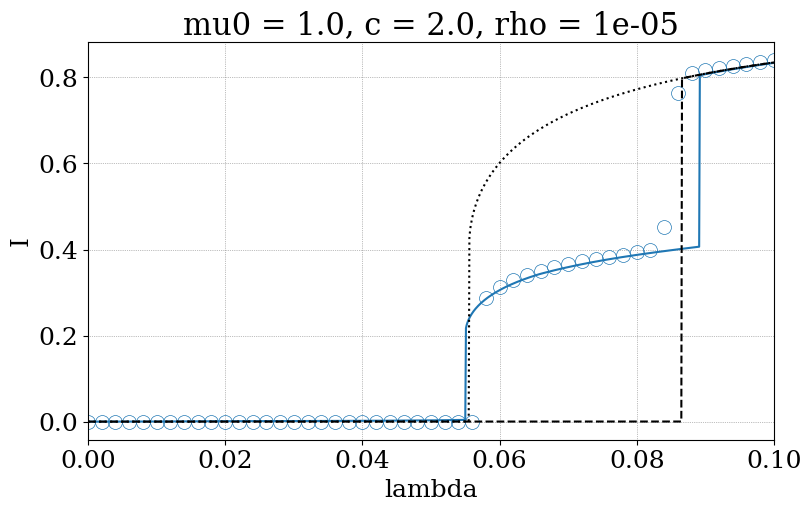

In [ ]:
fig, axs = plt.subplots(len(c_list), 1, figsize=(8, 5*len(c_list)), constrained_layout=True)
if len(c_list) == 1:
    axs = [axs]
for c_idx, c in enumerate(c_list):
    I = sim_results["I"]
    for e_idx, edge_num in enumerate(edge_num_list):
        I_rho = I.sel(rho=1.0).sel(c=c).sel(edge_num=edge_num).mean(dim="itr")/N
        I_rho.plot(ax=axs[c_idx], marker="o", markersize=10, ls="", markerfacecolor="none", markeredgewidth=0.5,color=colors[e_idx])
        ame_I=ame["I"]
        n_r = edge_num/2
        print(n_r)
        print(ame_I.dims)
        ame_I.sel(rho=1.0).sel(c=c).squeeze().plot(ax=axs[c_idx], color=colors[e_idx])

    # axs[c_idx].axvline(x=0.055, color="black", ls="--", alpha=0.5)
    # axs[c_idx].axvline(x=0.089, color="black", ls="--", alpha=0.5)
    axs[c_idx].set_title(f"c={c}")
    min_lambda = I.sel(c=c)["lambda"].min()
    max_lambda = I.sel(c=c)["lambda"].max()
    axs[c_idx].set_xlim(min_lambda, max_lambda)
    axs[c_idx].grid(True, linestyle=":")
    axs[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axs[c_idx].set_ylabel("I")
    else:
        axs[c_idx].set_ylabel("")
    r_ame["I"].sel(rho=1.0).sel(c=c).squeeze().plot(ax=axs[c_idx], ls=":", color="black")
    r_ame["I"].sel(rho=1e-5).sel(c=c).squeeze().plot(ax=axs[c_idx], ls="--", color="black")
plt.show()


NameError: name 'ame_results' is not defined

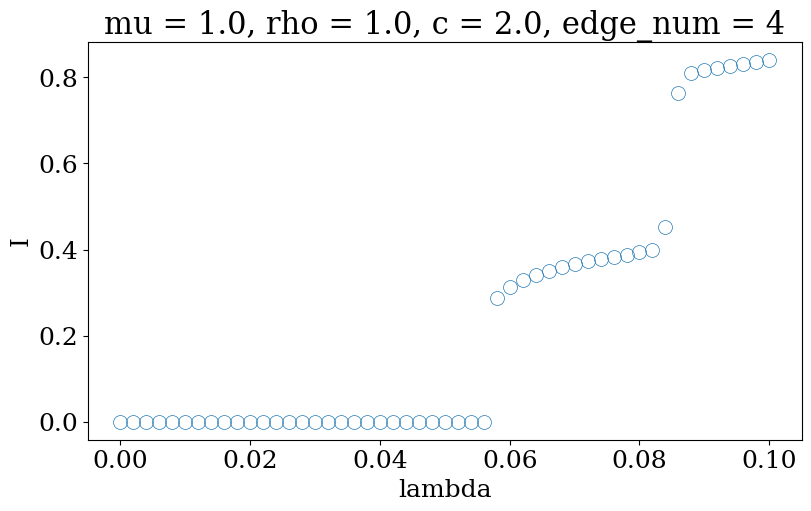

In [ ]:
fig, axs = plt.subplots(len(c_list), 1, figsize=(8, 5*len(c_list)), constrained_layout=True)
if len(c_list) == 1:
    axs = [axs]
for c_idx, c in enumerate(c_list):
    I = sim_results["I"]
    for e_idx, edge_num in enumerate(edge_num_list):
        I_rho = I.sel(rho=1.0).sel(c=c).sel(edge_num=edge_num).mean(dim="itr")/N
        I_rho.plot(ax=axs[c_idx], marker="o", markersize=10, ls="", markerfacecolor="none", markeredgewidth=0.5,color=colors[e_idx])
        ame_I=ame_results[c_idx]["I"]
        n_r = edge_num/2
        print(n_r)
        ame_I.sel(rho=1.0).sel(c=c).sel(n_r=n_r).squeeze().plot(ax=axs[c_idx], color=colors[e_idx])

    axs[c_idx].axvline(x=0.055, color="black", ls="--", alpha=0.5)
    axs[c_idx].axvline(x=0.089, color="black", ls="--", alpha=0.5)
    axs[c_idx].set_title(f"c={c}")
    min_lambda = I.sel(c=c)["lambda"].min()
    max_lambda = I.sel(c=c)["lambda"].max()
    axs[c_idx].set_xlim(min_lambda, max_lambda)
    axs[c_idx].grid(True, linestyle=":")
    axs[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axs[c_idx].set_ylabel("I")
    else:
        axs[c_idx].set_ylabel("")
plt.show()


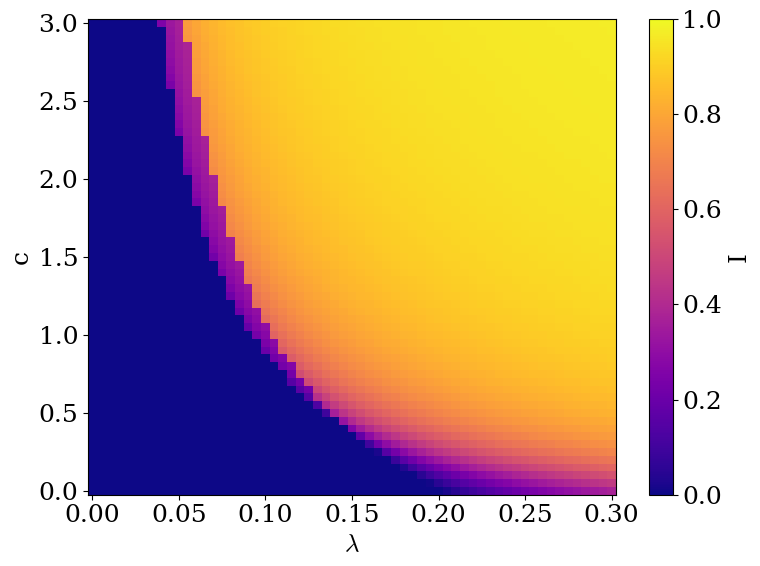

In [ ]:
is_final = "true"
index_cols = [] if is_final == "true" else ["time"]
index_cols.extend(["lambda", "mu0", "c", "rho"])

ame_path = os.path.abspath(
        os.path.join(
            '..',
            f'ame/sis/map/z={z}_z_bar={z_bar}n_r={4}/is_final={is_final}.csv'
            # f'c-lang/ame/sis/z={z}/is_final={is_final}.csv'
        )
    )
ame=pd.read_csv(ame_path)
ame = xr.Dataset.from_dataframe(ame.set_index(index_cols))
# Dataset は .plot() を直接使えないので、変数 I を 2D (lambda, c) でプロット
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ame["I"].squeeze().plot(x="lambda", y="c", cmap="plasma", ax=ax, vmin=0, vmax=1)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("c")
ax.set_title("")
plt.tight_layout()
plt.show()